## Setup

In [ ]:
# Package import and verification
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy import stats
import sklearn as sk

print( f"NumPy version:  \t{np.__version__}" )
print( f"Pandas version: \t{pd.__version__}" )
print( f"Seaborn version:\t{sns.__version__}" )
print( f"Scipy version:  \t{sp.__version__}" )
print( f"Scikit Learn version:  \t{sk.__version__}" )
print( "All packages loaded successfully!" )

In [ ]:
# Load data with explicit path
current_dir = os.getcwd()
fname = os.path.join(current_dir, "Peoples_Climate_Vote_Database_2024", "Peoples_Climate_Vote_Database_2024.xlsx")
df = pd.read_excel(fname)
print(f"Data shape: {df.shape}")
print("Data info:\n")
df.info()
print("Data loaded successfully!\n")

In [ ]:
# Immediate diagnostic checks
print("=== CRITICAL DIAGNOSTICS ===")
print(f"1. Missing 'Weighted Mean' values: {df['Weighted Mean'].isna().sum()} ({df['Weighted Mean'].isna().mean()*100:.1f}%)")
print(f"2. Unique countries: {df['Country'].nunique()}")
print(f"3. Unique questions (QID): {df['QID'].nunique()}")
print(f"4. Education categories: {df['Education'].unique().tolist()}")
print(f"5. Age categories: {df['Age'].unique().tolist()}")

### Helpers

In [ ]:
def pretty(text):
    print()
    print((len(text)+5)*'-')
    print(f" {text.title()}")
    print((len(text)+5)*'-')

def number(lst):
    for k, v in enumerate(lst, start=1):
        print(f"{k}.{v}")

def responses_for(df):
    pretty("response types")
    print(f"Detailed breakdown:")
    print(f"Unique responses: {df['Response'].nunique()}")
    print(f"Total responses:  {len(df)}")
    print(f"Most common response: '{df['Response'].mode().iloc[0]}'")
    
    pretty("full distribution")
    resp_occurances = df['Response'].value_counts()
    print(resp_occurances)

In [ ]:
# INSPECT start and end of frame
pretty("columns")
df.columns.tolist()


# pretty("head and tail")
# print(df.head())
# print(df.tail())


### Explore Key Variables

In [ ]:
pretty("unique countries")
print( f" {df['Country'].nunique()}= {number(df['Country'].unique())}" )

In [ ]:
pretty("unique questions")
print( f"{df['Question Text'].nunique()}= {number(df['Question Text'].unique())}" )
# print( f"{df['Question Text (Short)'].nunique()}= {number(df['Question Text (Short)'].unique())}" )

In [ ]:
responses_for(df)

### Isolate the target question data (QID 9)

In [7]:
# Extract QID 9 Data Frame
target_qid = 9
df_qid9 = df[df['QID'] == target_qid].copy()

pretty(f"target question analysis - qid {target_qid}")
print(f"Question: '{df_qid9['Question Text'].iloc[0][:100]}...'")
print(f"Response options by ID: {df_qid9['RID'].unique().tolist()}")
print(f"Response options: {df_qid9['Response'].unique().tolist()}")
print(f"Rows for target: {len(df_qid9)}")
print(f"Countries covered: {df_qid9['Country'].nunique()}")


-------------------------------------
 Target Question Analysis - Qid 9
-------------------------------------
Question: 'Should your country strengthen or weaken its commitments to address climate change?...'
Response options by ID: [1, 2, 3, 1000]
Response options: ['Strengthen', 'Keep them the same', 'Weaken', "Don't know"]
Rows for target: 2580
Countries covered: 73


In [11]:
# Keep only the relevant columns
explicit_cols = ["ID","CID","QID","RID","EID","AID","Country","Response","Education","Age","Weighted Mean"]
# responses_for(df_qid9[explicit_cols])

# Keep only the relevant columns
final_cols = ["ID","CID","QID","RID","EID","AID","Weighted Mean"]
df_ids = df_qid9[final_cols].copy()
# df_ids

#### Column Interpretations in `df_qid9`

- `ID`: Unique row identifier (not useful for analysis)
- `CID`: Country ID (1=Global, 2-73=individual countries)
- `QID`: Question ID (9 = "strengthen commitments" question)
- `RID`: Response ID (1=Strengthen, 2=Keep same, 3=Weaken, 1000=Don't know)
- `EID`: Education ID (1=All levels, 2=Never Attended, 3=u12, 4=12-19, 5=20+)
- `AID`: Age ID (1=All ages, 2=u18, 3=18-35, 4=36-59, 5=60+)\
 *EXTRA*
- `Country`: Country name
- `Response`: Text of response
- `Education`: Education level category
- `Age`: Age group category
- `Weighted Mean`: PERCENTAGE of respondents in that demographic giving that response

### Transform to Country-Level Dataset

In [13]:
# Pivot to get percentages for each response as columns
pretty("pivoting to country-demographic level")
df_pivoted = df_ids.pivot_table(
    index=['CID', 'EID', 'AID'],
    columns='RID',
    values='Weighted Mean',
    aggfunc='first'
).reset_index()

# Rename columns for easier handling
df_pivoted.columns.name = None
df_pivoted = df_pivoted.rename(columns={
    1: 'pct_strengthen',
    2: 'pct_keep_same',
    3: 'pct_weaken',
    1000: 'pct_dont_know'
})

print(f"Pivoted shape: {df_pivoted.shape}")
df_pivoted.head()


------------------------------------------
 Pivoting To Country-Demographic Level
------------------------------------------
Pivoted shape: (360, 7)


,CID,EID,AID,pct_strengthen,pct_keep_same,pct_weaken,pct_dont_know
0,1,1,1,80.0,13.0,5.0,2.0
1,1,1,2,83.0,10.0,3.0,1.0
2,1,1,3,81.0,13.0,4.0,1.0
3,1,1,4,79.0,13.0,6.0,2.0
4,1,1,5,79.0,14.0,5.0,3.0


## Analysis

### Predict country-level orverall support

In [14]:
# Filter to overall country totals (All Education [1], All Ages [1])
pretty("country-level totals")
df_country_totals = df_pivoted[
    (df_pivoted['EID'] == 1) & 
    (df_pivoted['AID'] == 1)
].copy()

print(f"Country totals shape: {df_country_totals.shape}")
print(df_country_totals.head())



-------------------------
 Country-Level Totals
-------------------------
Country totals shape: (73, 7)
    CID  EID  AID  pct_strengthen  pct_keep_same  pct_weaken  pct_dont_know
0     1    1    1            80.0           13.0         5.0            2.0
9     2    1    1            75.0           14.0         3.0            9.0
15    3    1    1            75.0            6.0        15.0            4.0
19    4    1    1            83.0            7.0         1.0            9.0
25    5    1    1            74.0            9.0        11.0            6.0


In [15]:
def extract_question_percentages(df, qid, response_mapping=None):
    """
    Extract percentages for a specific question across countries
    
    Parameters:
    -----------
    qid : int
        Question ID to extract
    response_mapping : dict, optional
        How to rename response columns
    """
    # Filter to question
    df_q = df[df['QID'] == qid].copy()
    
    # Filter to country totals
    df_q_totals = df_q[
        (df_q['Education'] == 'All Education') & 
        (df_q['Age'] == 'All Ages')
    ]
    
    # Pivot
    pivoted = df_q_totals.pivot_table(
        index='Country',
        columns='Response',
        values='Weighted Mean',
        aggfunc='first'
    ).reset_index()
    
    pivoted.columns.name = None
    
    # Rename columns
    if response_mapping:
        pivoted = pivoted.rename(columns=response_mapping)
    else:
        # Generic renaming: q{id}_response
        for col in pivoted.columns:
            if col != 'Country':
                pivoted = pivoted.rename(columns={col: f'q{qid}_{col.lower().replace(" ", "_").replace("'", "")}'})
    
    return pivoted

# Example: Extract worry about climate change (QID 2)
pretty(f"question 2 data")
df_q2 = extract_question_percentages(df, 2)
print(f"Shape: {df_q2.shape}")
df_q2.head()



--------------------
 Question 2 Data
--------------------
Shape: (73, 5)


,Country,q2_about_the_same,q2_dont_know,q2_less_worried,q2_more_worried
0,Afghanistan,7.0,2.0,13.0,78.0
1,Algeria,16.0,0.0,12.0,72.0
2,Argentina,46.0,0.0,3.0,51.0
3,Australia,25.0,2.0,22.0,51.0
4,Bangladesh,19.0,2.0,22.0,57.0


In [16]:
def create_country_feature_matrix(df, target_qid=9):
    """
    Create country-level dataset with all questions as features
    """
    # Start with target question
    target_df = extract_question_percentages(df, target_qid)
    # Rename target column
    target_df = target_df.rename(columns={'q9_strengthen': 'target_strengthen'})
    
    # Get all question IDs except target
    all_qids = sorted(df['QID'].unique())
    feature_qids = [qid for qid in all_qids if qid != target_qid]
    
    # Merge all questions
    merged_df = target_df.copy()
    
    for qid in feature_qids:
        feature_df = extract_question_percentages(df, qid)
        # Merge on country
        merged_df = pd.merge(merged_df, feature_df, on='Country', how='left')
    
    return merged_df

# Create feature matrix
pretty("complete feature matrix")
feature_matrix = create_country_feature_matrix(df, target_qid=9)
print(f"Shape: {feature_matrix.shape}")
print(f"Columns: {feature_matrix.columns.tolist()}")

feature_matrix.head()


----------------------------
 Complete Feature Matrix
----------------------------
Shape: (73, 72)
Columns: ['Country', 'q9_dont_know', 'q9_keep_them_the_same', 'target_strengthen', 'q9_weaken', 'q1_a_few_times_a_year', 'q1_daily', 'q1_dont_know', 'q1_never', 'q1_weekly', 'q2_about_the_same', 'q2_dont_know', 'q2_less_worried', 'q2_more_worried', 'q3_dont_know', 'q3_extremely', 'q3_not_at_all', 'q3_not_very', 'q3_somewhat', 'q3_very', 'q4_about_the_same_as_usual', 'q4_better_than_usual', 'q4_dont_know', 'q4_worse_than_usual', 'q5_a_little', 'q5_a_lot', 'q5_dont_know', 'q5_not_at_all', 'q6_dont_know', 'q6_neither_well_nor_badly', 'q6_somewhat_badly', 'q6_somewhat_well', 'q6_very_badly', 'q6_very_well', 'q7_dont_know', 'q7_neither_well_nor_badly', 'q7_somewhat_badly', 'q7_somewhat_well', 'q7_very_badly', 'q7_very_well', 'q8_big_business', 'q8_campaigners_and_activists', 'q8_dont_know', 'q8_faith_and_community_leaders', 'q8_government', 'q8_the_european_union_(eu)', 'q8_the_united_nations

,Country,q9_dont_know,q9_keep_them_the_same,target_strengthen,q9_weaken,q1_a_few_times_a_year,q1_daily,q1_dont_know,q1_never,q1_weekly,...,q13_no_-_they_should_work_separately,q13_yes_-_they_should_work_together_despite_their_disagreements,q14_about_the_same_as_now,q14_dont_know,q14_less_help,q14_more_help,q15_about_the_same_as_now,q15_dont_know,q15_less,q15_more
0,Afghanistan,9.0,14.0,75.0,3.0,7.0,54.0,3.0,7.0,30.0,...,3.0,94.0,2.0,0.0,1.0,97.0,7.0,1.0,2.0,91.0
1,Algeria,4.0,6.0,75.0,15.0,12.0,55.0,1.0,12.0,20.0,...,11.0,85.0,5.0,1.0,3.0,90.0,4.0,0.0,1.0,95.0
2,Argentina,9.0,7.0,83.0,1.0,38.0,29.0,0.0,8.0,24.0,...,5.0,86.0,13.0,7.0,1.0,79.0,19.0,2.0,1.0,79.0
3,Australia,6.0,9.0,74.0,11.0,33.0,28.0,0.0,11.0,27.0,...,7.0,87.0,13.0,4.0,10.0,73.0,13.0,7.0,12.0,68.0
4,Bangladesh,1.0,11.0,86.0,3.0,31.0,41.0,1.0,10.0,17.0,...,5.0,94.0,5.0,0.0,3.0,92.0,6.0,0.0,1.0,93.0


### Handle NaNs

In [17]:
# Check missing values
pretty("missing values analysis")
missing_summary = feature_matrix.isna().sum()
print("Missing values per column:")
print(missing_summary[missing_summary > 0])

# Options for handling:
# 1. Drop columns with too many missing (>30%)
# 2. Impute with mean/median
# 3. Impute with 0 for "Don't know" responses

# Recommended: Fill with 0 for "Don't know" type responses
feature_matrix_filled = feature_matrix.fillna(0)

# Verify
print(f"\nMissing after fill: {feature_matrix_filled.isna().sum().sum()}")


----------------------------
 Missing Values Analysis
----------------------------
Missing values per column:
Series([], dtype: int64)

Missing after fill: 0


## Supervised Learning Regression Model

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate target and features
X = feature_matrix_filled.drop(columns=['Country', 'target_strengthen'])
y = feature_matrix_filled['target_strengthen']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Target range: {y.min():.1f}% to {y.max():.1f}%")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X shape: (73, 70)
y shape: (73,)
Target range: 62.0% to 97.0%


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name=""):
    """Comprehensive evaluation for regression models"""
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
        'Train MAPE': np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100,
        'Test MAPE': np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
    }
    
    # Print results
    pretty(f"{model_name} evaluation")
    print(f"{'Metric':<15} {'Train':<10} {'Test':<10}")
    print("-" * 35)
    for metric in ['R²', 'RMSE', 'MAE', 'MAPE']:
        print(f"{metric:<15} {metrics[f'Train {metric}']:<10.3f} {metrics[f'Test {metric}']:<10.3f}")
    
    return metrics, y_test_pred

In [21]:
# Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Evaluate
lr_metrics, lr_predictions = evaluate_regression_model(
    lr_model, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression"
)

# Cross-validation for robustness
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, 
                                cv=5, scoring='r2')
print(f"Cross-validation R² scores: {lr_cv_scores}")
print(f"Mean CV R²: {lr_cv_scores.mean():.3f} (±{lr_cv_scores.std():.3f})")


---------------------------------
 Linear Regression Evaluation
---------------------------------
Metric          Train      Test      
-----------------------------------
R²              1.000      0.896     
RMSE            0.000      2.192     
MAE             0.000      1.767     
MAPE            0.000      2.153     
Cross-validation R² scores: [0.91881435 0.93237882 0.9332654  0.89394383 0.80971559]
Mean CV R²: 0.898 (±0.046)


In [22]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use GridSearchCV for hyperparameter tuning
rf_model = RandomForestRegressor(random_state=42)

# For computational efficiency with small dataset, use RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

rf_search = RandomizedSearchCV(
    rf_model, 
    param_grid,
    n_iter=20,  # Number of parameter combinations to try
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_scaled, y_train)

# Best model
rf_best = rf_search.best_estimator_
print(f"Best parameters: {rf_search.best_params_}")
print(f"Best CV R²: {rf_search.best_score_:.3f}")

# Evaluate
rf_metrics, rf_predictions = evaluate_regression_model(
    rf_best, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest"
)

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best CV R²: 0.757

-----------------------------
 Random Forest Evaluation
-----------------------------
Metric          Train      Test      
-----------------------------------
R²              0.959      0.600     
RMSE            1.866      4.305     
MAE             1.470      3.812     
MAPE            1.858      4.581     



---------------------
 Model Comparison
---------------------
                    Test R²  Test RMSE  Test MAE  Test MAPE
Linear Regression  0.896268   2.192215  1.767243   2.153467
Random Forest      0.600034   4.304646  3.811600   4.580958


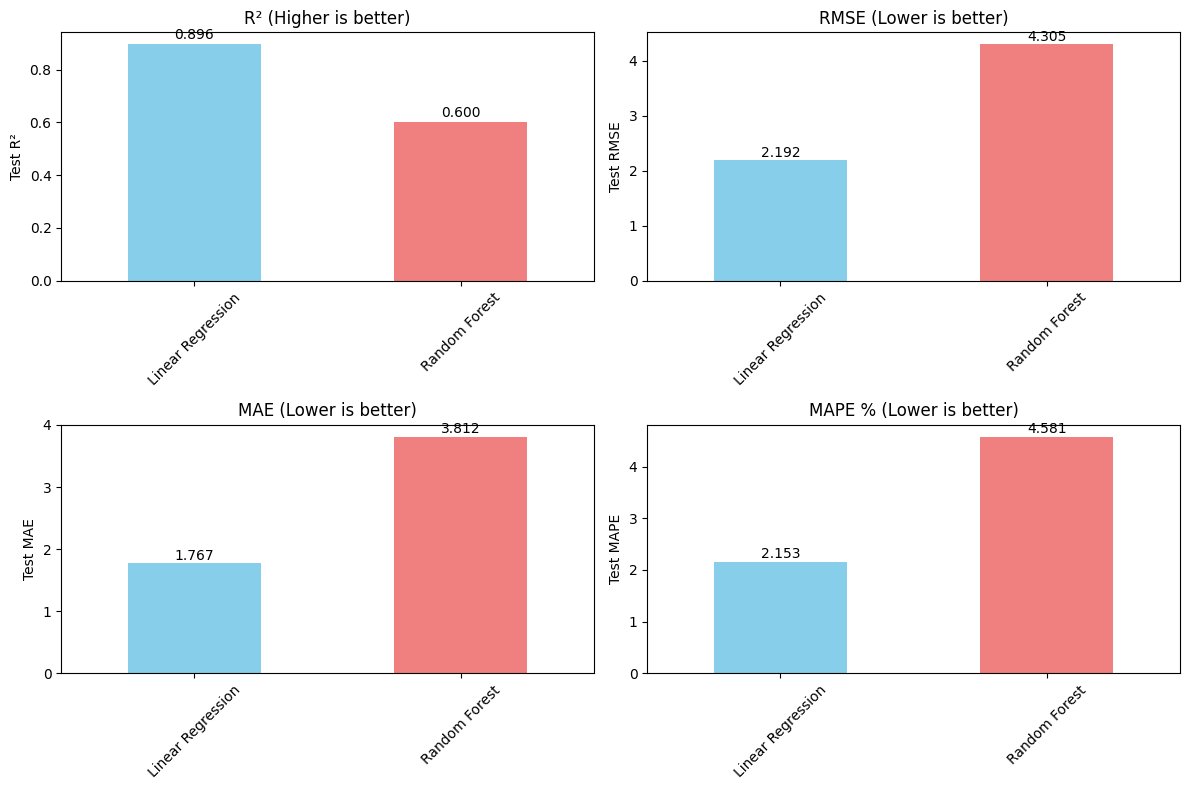

In [25]:
# Compare the models
def compare_models(metrics_dict):
    """Compare performance of multiple models"""
    pretty("model comparison")
    
    comparison_df = pd.DataFrame(metrics_dict).T
    comparison_df = comparison_df[['Test R²', 'Test RMSE', 'Test MAE', 'Test MAPE']]
    
    print(comparison_df)
    
    # Visual comparison
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    metrics_to_plot = ['Test R²', 'Test RMSE', 'Test MAE', 'Test MAPE']
    titles = ['R² (Higher is better)', 'RMSE (Lower is better)', 
              'MAE (Lower is better)', 'MAPE % (Lower is better)']
    
    for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
        ax = axes[idx//2, idx%2]
        comparison_df[metric].plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral'])
        ax.set_title(title)
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels
        for i, v in enumerate(comparison_df[metric]):
            ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return comparison_df

# Gather metrics
all_metrics = {
    'Linear Regression': lr_metrics,
    'Random Forest': rf_metrics
}

comparison_results = compare_models(all_metrics)


----------------------------------------------
 Linear Regression - Coefficient Magnitude
----------------------------------------------
Top 10 most important features:
                  feature  importance
1   q9_keep_them_the_same    5.995540
2               q9_weaken    5.339824
0            q9_dont_know    2.095213
55          q12_dont_know    1.464269
52          q11_dont_know    1.264004
57    q12_more_protection    1.222851
16            q3_somewhat    1.072098
17                q3_very    0.871172
21    q4_worse_than_usual    0.784935
3   q1_a_few_times_a_year    0.758993

Linear Regression - Importance by Question Topic:
                               Question  Total Importance
0                           Q9: Unknown         13.430577
11      Q12: Extreme weather protection          2.980509
3       Q3: Worry about next generation          2.885577
1        Q1: Think about climate change          2.472388
7   Q7: Business performance on climate          2.141781
10           

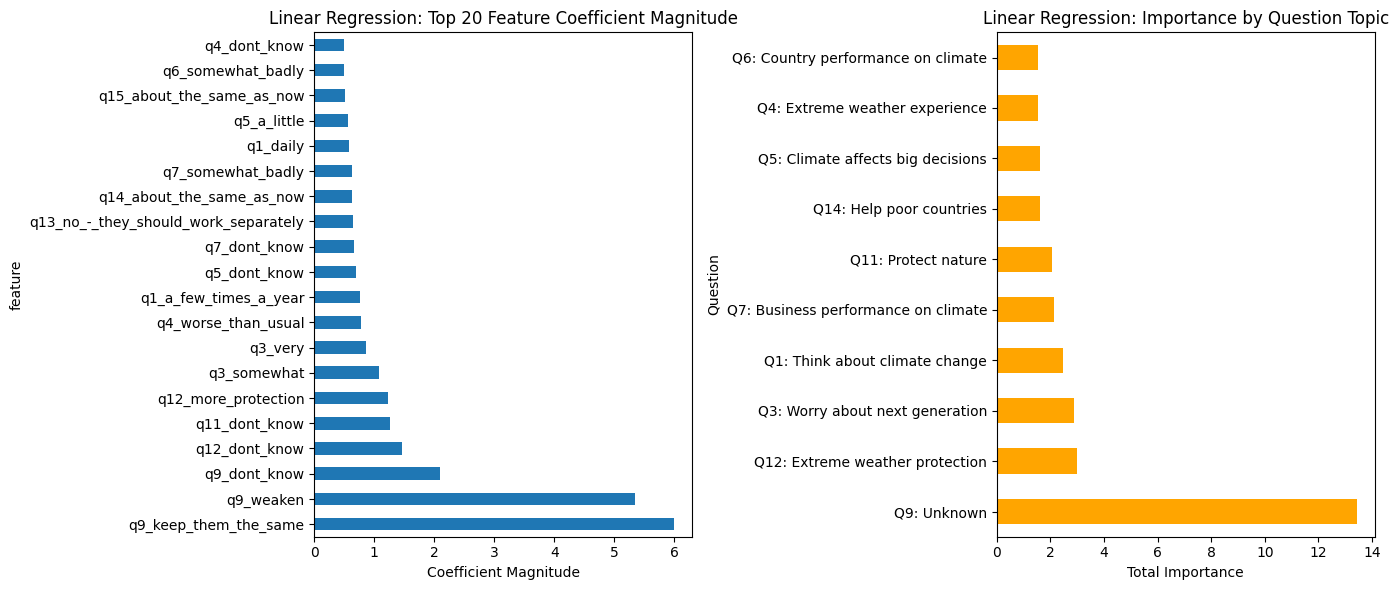


---------------------------------------
 Random Forest - Feature Importance
---------------------------------------
Top 10 most important features:
                      feature  importance
1       q9_keep_them_the_same    0.337735
57        q12_more_protection    0.267138
2                   q9_weaken    0.063693
65              q14_more_help    0.056091
54  q12_about_the_same_as_now    0.055610
69                   q15_more    0.045117
0                q9_dont_know    0.016113
15                q3_not_very    0.010121
62  q14_about_the_same_as_now    0.008894
49           q10_very_quickly    0.008091

Random Forest - Importance by Question Topic:
                               Question  Total Importance
0                           Q9: Unknown          0.417541
11      Q12: Extreme weather protection          0.325441
13             Q14: Help poor countries          0.069735
14               Q15: Climate education          0.056858
9          Q10: Energy transition speed          0.0

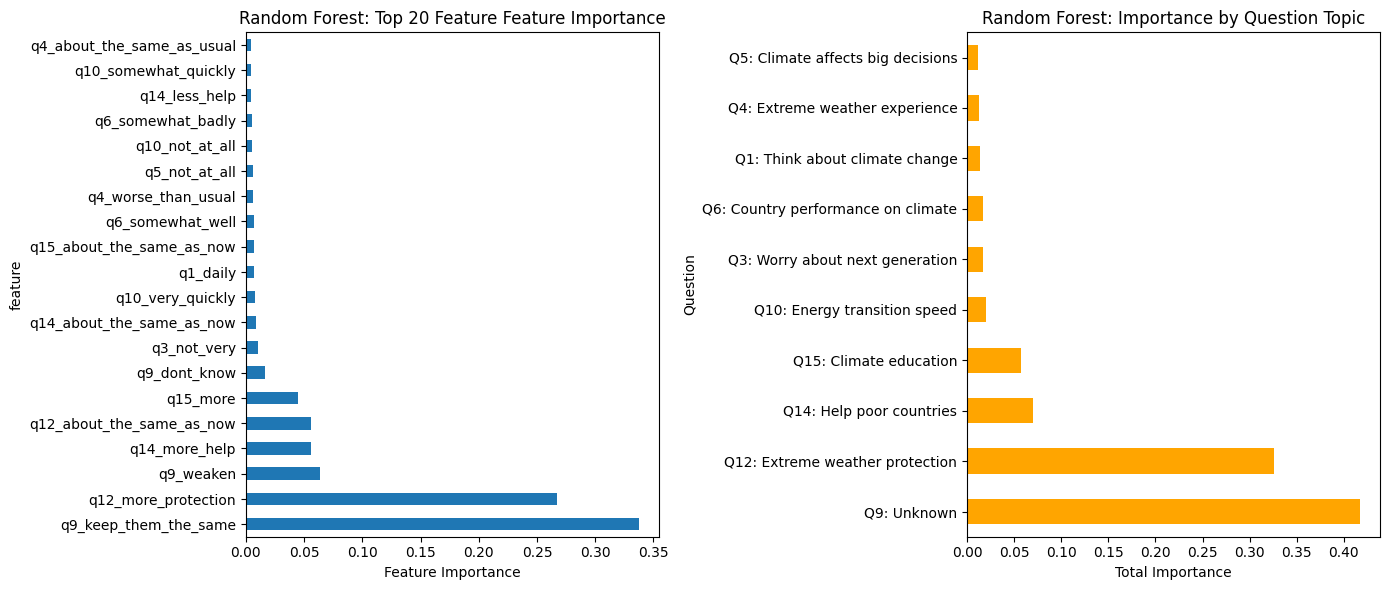

In [26]:
# Feature importance analysis
def analyze_feature_importance(model, feature_names, model_name="Model"):
    """Analyze and visualize feature importance"""
    
    if hasattr(model, 'coef_'):  # Linear Regression
        importance = np.abs(model.coef_)
        importance_type = "Coefficient Magnitude"
    elif hasattr(model, 'feature_importances_'):  # Random Forest
        importance = model.feature_importances_
        importance_type = "Feature Importance"
    else:
        print(f"No feature importance available for {model_name}")
        return None
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    pretty(f"{model_name} - {importance_type}")
    print("Top 10 most important features:")
    print(importance_df.head(10))
    
    # Group features by question to see which attitudes matter most
    feature_importance_by_question = {}
    for feature, imp in zip(feature_names, importance):
        # Extract question number from feature name (e.g., 'q2_more_worried' -> Q2)
        if feature.startswith('q'):
            q_num = feature.split('_')[0][1:]  # Remove 'q' prefix
            if q_num.isdigit():
                q_num = int(q_num)
                feature_importance_by_question[q_num] = feature_importance_by_question.get(q_num, 0) + imp
    
    # Map question numbers to topics
    question_topics = {
        1: "Think about climate change",
        2: "Worry change vs last year", 
        3: "Worry about next generation",
        4: "Extreme weather experience",
        5: "Climate affects big decisions",
        6: "Country performance on climate",
        7: "Business performance on climate",
        8: "Who has most impact",
        10: "Energy transition speed",
        11: "Protect nature",
        12: "Extreme weather protection",
        13: "International cooperation",
        14: "Help poor countries",
        15: "Climate education"
    }
    
    # Create question-level importance
    question_importance = pd.DataFrame([
        {'Question': f"Q{q}: {question_topics.get(q, 'Unknown')}", 
         'Total Importance': imp}
        for q, imp in feature_importance_by_question.items()
    ]).sort_values('Total Importance', ascending=False)
    
    print(f"\n{model_name} - Importance by Question Topic:")
    print(question_importance)
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Top 20 features
    importance_df.head(20).plot(kind='barh', x='feature', y='importance', 
                                 ax=ax1, legend=False)
    ax1.set_title(f'{model_name}: Top 20 Feature {importance_type}')
    ax1.set_xlabel(importance_type)
    
    # Question-level importance
    question_importance.head(10).plot(kind='barh', x='Question', y='Total Importance',
                                       ax=ax2, legend=False, color='orange')
    ax2.set_title(f'{model_name}: Importance by Question Topic')
    ax2.set_xlabel('Total Importance')
    
    plt.tight_layout()
    plt.show()
    
    return importance_df, question_importance

# Analyze both models
lr_importance, lr_question_importance = analyze_feature_importance(
    lr_model, X.columns.tolist(), "Linear Regression"
)

rf_importance, rf_question_importance = analyze_feature_importance(
    rf_best, X.columns.tolist(), "Random Forest"
)

### Predict demographic-level support within countries

## Coursework 1

In [27]:
# Keep only rows where QID = 10 and use the row all education level, ignore the global
# filter to only have the relevant rows
df_q10 = df[ (df['QID'] == 10) & (df['CID'] != 1) & 
             (df['AID'] != 1) & (df['AID'] != 2) & (df['EID'] == 1) 
        ][ 
        ['Country', 'Age', 'RID', 'Weighted Mean'] 
    ].copy()
df_q10.head()

,Country,Age,RID,Weighted Mean
20226,Afghanistan,18 to 35,1,39.0
20227,Afghanistan,18 to 35,2,11.0
20228,Afghanistan,18 to 35,3,39.0
20229,Afghanistan,18 to 35,4,4.0
20230,Afghanistan,18 to 35,1000,7.0


In [ ]:
df_dk = df_q10[(df_q10['RID'] == 1000)][
    ['Country', 'Age', 'Weighted Mean']
    ].rename(columns={'Weighted Mean': 'WM_DK'})
df_dk.head()

In [ ]:
finaldf = pd.merge(df_q10, df_dk, how='left', on=('Country', 'Age'))
finaldf.head()


In [ ]:
mask_valid = (finaldf['RID'] != 1000) & finaldf['WM_DK'].notna() & ((100 - finaldf['WM_DK']) > 0)
finaldf['Weighted Mean (renorm)'] = np.where(
    mask_valid,
    (finaldf['Weighted Mean'] / (100 - finaldf['WM_DK'])) * 100,
    np.nan  # DK rows or invalid denominator → leave as NaN
)
finaldf.head()

In [ ]:
finaldf = finaldf[finaldf['RID'] != 1000].copy()
finaldf.head()

In [ ]:
# LIKERT SCALE
mapping = {1: 1, 2: 2/3, 3: 1/3, 4: 0}
finaldf['RID'] = finaldf['RID'].replace(mapping)
finaldf.head()

In [ ]:
# Compute the weighted score per row
finaldf['score'] = finaldf['RID'] * finaldf['Weighted Mean (renorm)']
finaldf

In [ ]:
# Aggregate by Country × Age (sum or mean — usually sum for weighted totals)
agg = finaldf.groupby(['Country', 'Age'], as_index=False)['score'].sum()
agg

In [ ]:
# Pivot so columns are age groups and rows are countries
table = agg.pivot(index='Country', columns='Age', values='score')
table.head()

In [ ]:
# HEATMAP OF AGE SCORES BY COUNTRY
table = table.replace(0, np.nan)
plt.figure(figsize=(10,8))
sns.heatmap(table, annot=True, cmap='YlGnBu', cbar_kws={'label': 'Score'})
plt.title('Age Group Scores by Country')
plt.show()

In [ ]:
# Compute the age gap
table['Age Gap'] = table['18 to 35'] - table['36 to 59']

# Sort countries by size of gap (largest → smallest)
table_sorted = table.sort_values('Age Gap', ascending=False)

# Set up the plot style
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(
    data=table_sorted,
    x=table_sorted.index,
    y='Age Gap',
    palette='coolwarm',
)

# Add a horizontal line at 0 (no difference)
plt.axhline(0, color='black', linewidth=1, linestyle='--')

# Titles and labels
plt.title('Age Gap in Urgency to Replace Fossil Fuels by Country', fontsize=16, weight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Age Gap (18–35 minus 36–59)', fontsize=12)

# Rotate and tidy x-axis labels
plt.xticks(rotation=90, ha='center', fontsize=10)

# Annotate bars with exact values
for p in ax.patches:
    value = p.get_height()
    if not np.isnan(value):
        ax.annotate(
            f'{value:.1f}',
            (p.get_x() + p.get_width() / 2, value),
            ha='center',
            va='bottom' if value >= 0 else 'top',
            fontsize=9,
            color='black'
        )

plt.tight_layout()
plt.show()

#Positive values → younger respondents are more urgent about replacing fossil fuels.

#Negative values → older respondents are more urgent.

#Near zero → little or no age difference in opinions.

In [ ]:
table['Age Gap'].dropna().describe()

In [ ]:
from scipy import stats

gaps = table['Age Gap'].dropna()
t_stat, p_value = stats.ttest_1samp(gaps, 0)
print(f"T-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

#If p < 0.05: The average gap is significantly different from 0 → there is a consistent age difference globally.

#If p >= 0.05: No significant evidence of a consistent global pattern.

The negative t-value indicates that, on average, older respondents reported *slightly higher urgency* than younger respondents. However, the difference is small and not statistically significant (t = –1.07, p = 0.29).
This means there is no strong evidence of a consistent directional age gap across countries, the generational differences appear mixed or negligible overall.

In [ ]:
# Drop NaN values from the Age Gap column
gaps = table['Age Gap'].dropna()

# Take absolute values (ignore direction)
abs_gaps = np.abs(gaps)

# One-sample t-test against 0
t_stat, p_value = stats.ttest_1samp(abs_gaps, 0)

# Print results
print(f"T-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")
print(f"Mean absolute age gap = {abs_gaps.mean():.2f}")

A one-sample t-test on the absolute age gaps (M = 2.76, t = 7.998, p < 0.001) indicated that there are statistically significant differences in urgency between younger (18–35) and older (36–59) respondents across countries.
This suggests that, although the direction of the difference may vary, age consistently matters — with an average gap of roughly 2.8 percentage points.


In [ ]:
# DISTRIBUTION OF AGE GAPS ACROSS COUNTRIES
plt.figure(figsize=(8,5))
sns.histplot(table['Age Gap'], bins=25, kde=True, color='teal')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of Age Gaps Across Countries')
plt.xlabel('Age Gap (18–35 minus 36–59)')
plt.ylabel('Number of Countries')
plt.show()



In [ ]:
# Drop NaNs
gaps = table['Age Gap'].dropna()
abs_gaps = np.abs(gaps)

# Create a tidy DataFrame for plotting
plot_df = (
    {
        'Signed Gap': gaps,
        'Absolute Gap': abs_gaps
    }
)

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(12,5))

# --- Subplot 1: Signed gaps ---
plt.subplot(1, 2, 1)
sns.histplot(gaps, bins=20, kde=True, color='skyblue')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Signed Age Gaps Across Countries', fontsize=13, weight='bold')
plt.xlabel('Urgency Difference (18–35 minus 36–59)')
plt.ylabel('Number of Countries')
plt.text(0.02, plt.ylim()[1]*0.9, f"Mean = {gaps.mean():.2f}", fontsize=10, color='black')

# --- Subplot 2: Absolute gaps ---
plt.subplot(1, 2, 2)
sns.histplot(abs_gaps, bins=20, kde=True, color='salmon')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Magnitude of Age Gaps Across Countries', fontsize=13, weight='bold')
plt.xlabel('Absolute Urgency Difference')
plt.ylabel('')
plt.text(0.02, plt.ylim()[1]*0.9, f"Mean = {abs_gaps.mean():.2f}", fontsize=10, color='black')

plt.suptitle('Distribution of Age Gaps in Urgency to Replace Fossil Fuels', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()


**IGNORE USA**

In [ ]:
# NO REAL TREND DUE TO US SKEW
table_no_usa = table.drop('United States of America (the)', errors='ignore')


In [ ]:
gaps_no_usa = table_no_usa['Age Gap'].dropna()
t_signed, p_signed = stats.ttest_1samp(gaps_no_usa, 0)
print(f"Signed test: mean={gaps_no_usa.mean():.2f}, t={t_signed:.3f}, p={p_signed:.4f}")


Across countries, the mean difference in urgency scores between younger (18–35) and older (36–59) respondents was –0.84 percentage points (t = –2.23, p = 0.03).
This result is statistically significant, suggesting that older adults express slightly greater urgency about replacing fossil fuels than younger adults on average.
However, the size of the difference is small (<1 percentage point), indicating that the effect, while significant, is modest in magnitude.

In [ ]:
abs_gaps_no_usa = np.abs(gaps_no_usa)
t_abs, p_abs = stats.ttest_1samp(abs_gaps_no_usa, 0)
print(f"Absolute test: mean={abs_gaps_no_usa.mean():.2f}, t={t_abs:.3f}, p={p_abs:.4f}")


In [ ]:
## Coursework 2

## TODO

### Supervised Learning Model
- Used whenever we want to predict a certain outcome from a given input
- Goal is to create a function that maps inputs to outputs.
- We have examples of input/output pairs
- We build a machine learning model from these input/output pairs -> training set
- Our goal is to make accurate predictions for new, never-before-seen data
- Regression: Output value is quantitative

#### Regression
- The goal of regression is to predict the value of one or more continuous target variables `t` given the value of a D-dimensional vector `x` of input variables.
- Regression is similar to classification: you have a number of input features, and you want to predict an output feature. In classification, this output feature is either binary or categorical. With regression, it is a **real‐valued number**.
- Typically, regression algorithms model the output as a linear combination of the inputs.

#### Decisioon Trees

##### Random Forests
As we’ve seen, fully‐grown decision trees will almost always overfit data.
- Low model bias, high model variance.
- In other words, small changes in dataset will result in very different decision tree.
- Example: Two models on the right trained on different subsets of the same data.
Random Forest Idea: Build many decision trees and have them vote (use the most popular prediction).

##### Building Many Trees
Big fundamental problem: We only have one training set.
How can we build many trees using one training set?

###### Bagging: Short for Bootstrap AGGregatING.
- Generate bootstrap resamples of training data.
- Fit one model for each resample.
- Final model = average predictions of each small model.
- Invented by Leo Breiman in 1994 (Berkeley Statistics!)

Bagging often isn’t enough to reduce model variance!
- Decision trees often look very similar to each other.
- E.g. one strong feature always used for first split.
Idea: Only use a sample of m features at each split.
- Usually `m = sqrt(p)` for decision trees used for classification.
- Here `p` is the number of features.
Algorithm creates individual trees, each overfit in a different way.
- The hope is that the the overall forest has low variance.

Bootstrap training data `T` times. For each resample, fit a decision tree by doing the following:
- Start with data in one node. Until all nodes pure:
- Pick an impure node.
- Pick a random subset of m features. Pick the best feature x and split value β such that the loss of the resulting split is minimized, e.g. `x = petal_width`, `β = 0.8` has loss 0.66.
- Split data into two nodes, one where `x < β`, and one where `x ≥ β`.
To predict, ask the `T` decision trees for their predictions and take majority vote.

Avoiding Overfitting with Heuristics

- Versatile: does both regression and classification.
- Invariant to feature scaling and translation.
- Automatic feature selection.
- Nonlinear decision boundaries without complicated feature engineering.
- Doesn’t overfit as often as other nonlinear models (e.g. polynomial features).
- Example of ensemble method: combine the knowledge of many simple models to make a sophisticated model.
- Example of using bootstrap to reduce model variance.

### Performance Evaluation
- Using the accuracy of the model
- Confusion matrices are often better at evaluating classifiers than accuracy metrics are, especially when
dealing with unbalanced datasets.
Consider building a classifier that aims to predict the prevalence of a rare disease. If only 5% of the
people have the disease, a classifier that always predicts healthy individuals will achieve an accuracy
score of 95%.
However, the classifier is relatively useless since it never predicts any instances of the disease

### Clustering Analysis
- Apply an unsupervised method (e.g., k-means, hierarchical clustering, PCA).